## Importing Dependencies

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading Constrained Realizations Into Dataframe

In [2]:
filename = "./constrainedMilkyWay.hdf5"
output = "Output1"

cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "parentIndex",
    "nodeLabelLMC",
    "nodeLabelIsLMCSubhalo",
    "nodeLabelWasLMCSubhalo",
    "basicTimeLastIsolated",
    "nodeIsIsolated",
    "satelliteBoundMass",
    "darkMatterProfileScale",
]

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"
    out_path = f"Outputs/{output}"

    print("Number of nodeData columns:", len(f[node_path].keys()))

    print("\nColumns being loaded:")
    for col in cols:
        dset = f[f"{node_path}/{col}"]
        print(col, dset.shape, dset.dtype)

    data = {col: f[f"{node_path}/{col}"][:] for col in cols}

    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

constrained_df = pd.DataFrame(data)

tree_id = np.full(len(constrained_df), -1, dtype=np.int64)

for start, count, idx in zip(tree_start, tree_count, tree_index):
    start = int(start)
    count = int(count)
    idx = int(idx)

    tree_id[start:start + count] = idx

constrained_df["tree_id"] = tree_id

constrained_df["absolute_distance"] = np.linalg.norm(
    constrained_df[["satellitePositionX", "satellitePositionY", "satellitePositionZ"]].to_numpy(),
    axis=1
)


constrained_df = constrained_df[constrained_df["nodeIsIsolated"] != 1].reset_index(drop=True)

print(constrained_df["nodeIsIsolated"].value_counts())
print(constrained_df["tree_id"].max())
constrained_df.describe()

Number of nodeData columns: 25

Columns being loaded:
satellitePositionX (1315643,) float64
satellitePositionY (1315643,) float64
satellitePositionZ (1315643,) float64
basicMass (1315643,) float64
nodeIndex (1315643,) int64
parentIndex (1315643,) int64
nodeLabelLMC (1315643,) int64
nodeLabelIsLMCSubhalo (1315643,) int64
nodeLabelWasLMCSubhalo (1315643,) int64
basicTimeLastIsolated (1315643,) float64
nodeIsIsolated (1315643,) int64
satelliteBoundMass (1315643,) float64
darkMatterProfileScale (1315643,) float64
nodeIsIsolated
0    1305643
Name: count, dtype: int64
10000


,satellitePositionX,satellitePositionY,satellitePositionZ,basicMass,nodeIndex,parentIndex,nodeLabelLMC,nodeLabelIsLMCSubhalo,nodeLabelWasLMCSubhalo,basicTimeLastIsolated,nodeIsIsolated,satelliteBoundMass,darkMatterProfileScale,tree_id,absolute_distance
count,1.305643e+06,1.305643e+06,1.305643e+06,1.305643e+06,1.305643e+06,1.305643e+06,1.305643e+06,1.305643e+06,1.305643e+06,1.305643e+06,1305643.0,1.305643e+06,1.305643e+06,1.305643e+06,1.305643e+06
mean,-7.814839e-04,4.323506e-04,-2.778149e-04,5.180254e+09,3.933796e+03,1.985995e+02,7.618468e-03,7.295639e-02,1.204472e-01,6.785109e+00,0.0,1.240518e+09,1.818167e-03,5.004321e+03,3.785970e-01
std,3.960263e-01,3.999778e-01,3.979638e-01,2.092674e+10,4.713430e+03,1.327303e+03,8.695075e-02,2.600650e-01,3.254838e-01,3.734497e+00,0.0,7.460686e+09,1.462822e-03,2.887498e+03,5.760723e-01
min,-6.331353e+00,-6.131210e+00,-6.868358e+00,9.985536e+07,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.187036e-01,0.0,9.777543e+07,1.704533e-04,1.000000e+00,7.759551e-04
25%,-8.319585e-02,-8.273547e-02,-8.339554e-02,3.474183e+08,1.060000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.596341e+00,0.0,1.382331e+08,1.030757e-03,2.506000e+03,1.089420e-01
50%,-2.147369e-05,2.572454e-04,-1.767208e-04,7.569244e+08,3.960000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.372848e+00,0.0,2.199031e+08,1.411349e-03,5.005000e+03,1.894932e-01
75%,8.309595e-02,8.315063e-02,8.302065e-02,2.142868e+09,7.936000e+03,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.791047e+00,0.0,4.846071e+08,2.068407e-03,7.507000e+03,3.359985e-01
max,6.873135e+00,6.367017e+00,6.335718e+00,4.979671e+11,1.541300e+04,1.493400e+04,1.000000e+00,1.000000e+00,1.000000e+00,1.380048e+01,0.0,4.968549e+11,4.235080e-02,1.000000e+04,7.530630e+00


## Loading Unconstrained Realizations Into Dataframe

In [3]:
filename = "./unconstrainedMilkyWay.hdf5"
output = "Output1"

cols = [
    "satellitePositionX",
    "satellitePositionY",
    "satellitePositionZ",
    "basicMass",
    "nodeIndex",
    "parentIndex",
    "basicTimeLastIsolated",
    "nodeIsIsolated",
    "satelliteBoundMass"
]

with h5py.File(filename, "r") as f:
    node_path = f"Outputs/{output}/nodeData"
    out_path = f"Outputs/{output}"

    print("Number of nodeData columns:", len(f[node_path].keys()))

    print("\nColumns being loaded:")
    for col in cols:
        dset = f[f"{node_path}/{col}"]
        print(col, dset.shape, dset.dtype)

    data = {col: f[f"{node_path}/{col}"][:] for col in cols}

    tree_start = f[f"{out_path}/mergerTreeStartIndex"][:]
    tree_count = f[f"{out_path}/mergerTreeCount"][:]
    tree_index = f[f"{out_path}/mergerTreeIndex"][:]

unconstrained_df = pd.DataFrame(data)

tree_id = np.full(len(unconstrained_df), -1, dtype=np.int64)

for start, count, idx in zip(tree_start, tree_count, tree_index):
    start = int(start)
    count = int(count)
    idx = int(idx)

    tree_id[start:start + count] = idx

unconstrained_df["tree_id"] = tree_id

unconstrained_df["absolute_distance"] = np.linalg.norm(
    unconstrained_df[["satellitePositionX", "satellitePositionY", "satellitePositionZ"]].to_numpy(),
    axis=1
)

unconstrained_df = unconstrained_df[unconstrained_df["nodeIsIsolated"] != 1].reset_index(drop=True)

print(unconstrained_df["nodeIsIsolated"].value_counts())
print(unconstrained_df["tree_id"].max())

# print(unconstrained_df["absolute_distance"].describe())
unconstrained_df.describe()


Number of nodeData columns: 22

Columns being loaded:
satellitePositionX (1316289,) float64
satellitePositionY (1316289,) float64
satellitePositionZ (1316289,) float64
basicMass (1316289,) float64
nodeIndex (1316289,) int64
parentIndex (1316289,) int64
basicTimeLastIsolated (1316289,) float64
nodeIsIsolated (1316289,) int64
satelliteBoundMass (1316289,) float64
nodeIsIsolated
0    1306289
Name: count, dtype: int64
10000


,satellitePositionX,satellitePositionY,satellitePositionZ,basicMass,nodeIndex,parentIndex,basicTimeLastIsolated,nodeIsIsolated,satelliteBoundMass,tree_id,absolute_distance
count,1.306289e+06,1.306289e+06,1.306289e+06,1.306289e+06,1.306289e+06,1.306289e+06,1.306289e+06,1306289.0,1.306289e+06,1.306289e+06,1.306289e+06
mean,-3.427843e-04,1.099983e-04,-2.181564e-04,4.636677e+09,3.468431e+03,1.595271e+02,6.617021e+00,0.0,1.002039e+09,5.002168e+03,4.250127e-01
std,4.352162e-01,4.370379e-01,4.355844e-01,2.048671e+10,4.441853e+03,1.135077e+03,3.750053e+00,0.0,6.872080e+09,2.886675e+03,6.241099e-01
min,-6.485749e+00,-6.394070e+00,-6.299679e+00,9.992243e+07,2.000000e+00,1.000000e+00,2.403181e-01,0.0,9.736856e+07,1.000000e+00,3.405982e-04
25%,-9.550487e-02,-9.559107e-02,-9.581548e-02,3.451696e+08,1.080000e+02,1.000000e+00,3.401292e+00,0.0,1.381042e+08,2.501000e+03,1.268292e-01
50%,7.881377e-05,5.786482e-05,-7.872540e-05,7.490332e+08,3.400000e+02,1.000000e+00,6.141846e+00,0.0,2.194643e+08,5.002000e+03,2.165391e-01
75%,9.538061e-02,9.569369e-02,9.542683e-02,2.104780e+09,7.004000e+03,1.000000e+00,9.549260e+00,0.0,4.801478e+08,7.504000e+03,3.837252e-01
max,6.533396e+00,6.133545e+00,6.710900e+00,4.974793e+11,1.562600e+04,1.487600e+04,1.380048e+01,0.0,4.840876e+11,1.000000e+04,7.722445e+00


## Constants

In [4]:
min_smc_mass = 5.0e9
max_smc_mass = 8.0e9

min_smc_distance = 0.02
max_smc_distance = 0.04

total_tree_count = len(tree_start)
print(f"Total number of merger trees: {total_tree_count}")

Total number of merger trees: 10000


## Finding SMC Candidates In Constrained Data

In [5]:
smc_candidate_mask = (
    (constrained_df["nodeLabelWasLMCSubhalo"]) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

selected = constrained_df[smc_candidate_mask]
selected_ids = selected["tree_id"].tolist()
unique_selected_ids = set(selected_ids)
tree_id_with_multiple_candidates = selected["tree_id"].value_counts()
trees_with_multiple_candidates = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates > 1].index.tolist()
trees_with_single_candidate = tree_id_with_multiple_candidates[tree_id_with_multiple_candidates == 1].index.tolist()

print(selected.columns)
print("Selected tree IDs:", selected_ids)
print("Trees with multiple candidates:", trees_with_multiple_candidates)
print("Trees with single candidate:", trees_with_single_candidate)
print("Number selected:", len(selected))
print("Number of unique tree IDs:", len(unique_selected_ids))
print("Number of trees with multiple candidates:", len(trees_with_multiple_candidates))
print("Number of trees with single candidate:", len(trees_with_single_candidate))


Index(['satellitePositionX', 'satellitePositionY', 'satellitePositionZ',
       'basicMass', 'nodeIndex', 'parentIndex', 'nodeLabelLMC',
       'nodeLabelIsLMCSubhalo', 'nodeLabelWasLMCSubhalo',
       'basicTimeLastIsolated', 'nodeIsIsolated', 'satelliteBoundMass',
       'darkMatterProfileScale', 'tree_id', 'absolute_distance'],
      dtype='str')
Selected tree IDs: [9910, 9838, 9990, 9787, 9971, 9950, 9761, 9859, 9656, 9785, 9736, 9608, 9480, 9550, 9670, 9858, 9681, 9585, 9806, 9542, 9887, 9781, 9192, 9526, 9475, 9810, 9478, 9446, 9048, 9137, 9379, 9400, 8985, 9685, 9334, 9994, 9201, 8840, 9324, 9428, 9158, 8780, 9380, 8505, 8969, 9357, 9332, 9551, 9964, 8825, 8995, 9462, 9326, 8729, 9278, 8247, 8913, 8681, 9682, 9230, 9635, 8151, 8007, 8710, 9349, 8345, 8973, 7640, 7767, 7678, 8755, 7497, 8673, 8799, 9530, 8532, 9170, 7431, 8831, 7017, 9930, 7224, 7239, 7054, 7481, 6977, 8071, 8134, 8445, 8086, 9697, 8246, 6440, 6571, 7049, 8222, 9775, 8039, 6449, 7816, 6475, 8035, 6615, 7783, 6504

## SMC Candidates of trees with Multiple Candidates

In [6]:
special_smc_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_multiple_candidates)) &
    (constrained_df["nodeLabelWasLMCSubhalo"]) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

special_candidates = constrained_df[special_smc_candidate_mask]
print("Number of special candidates:", len(special_candidates))

Number of special candidates: 24


## SMC Candidates from trees with only one SMC

In [7]:
regular_candidate_mask = (
    (constrained_df["tree_id"].isin(trees_with_single_candidate)) &
    (constrained_df["nodeLabelWasLMCSubhalo"]) &
    (constrained_df["basicMass"] > min_smc_mass) &
    (constrained_df["basicMass"] < max_smc_mass) &
    (constrained_df["absolute_distance"] > min_smc_distance) &
    (constrained_df["absolute_distance"] < max_smc_distance)
)

regular_candidates = constrained_df[regular_candidate_mask]
print("Number of unique candidates:", len(regular_candidates))


Number of unique candidates: 594


## Histograms of Infall times of Regular Candidates vs Special Candidates

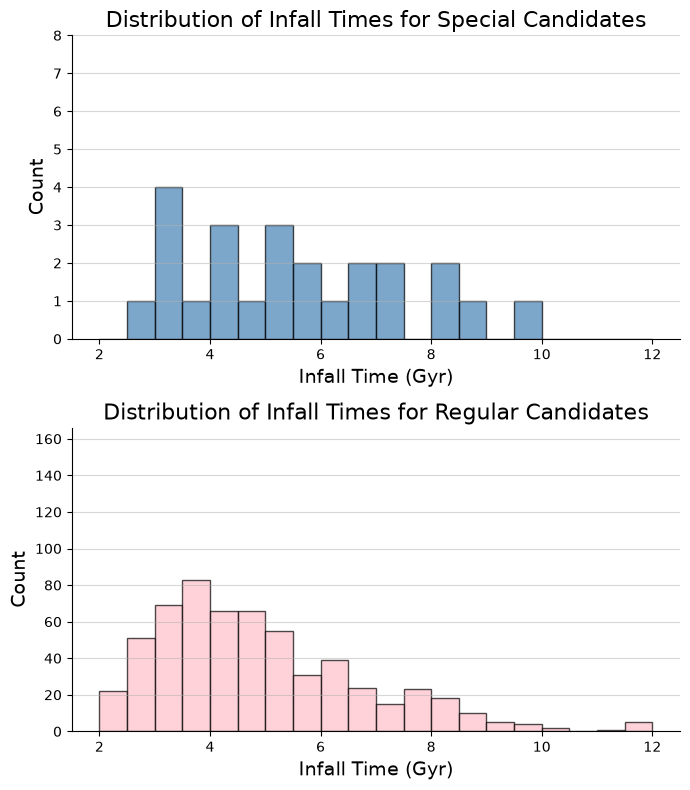

In [8]:
fig, ax = plt.subplots(2, 1, figsize = (7, 8))
bins = np.arange(2, 12.5, 0.5)

ax[0].hist(special_candidates["basicTimeLastIsolated"], bins=bins, color = "steelblue", edgecolor='black', alpha=0.7)
ax[0].set_title("Distribution of Infall Times for Special Candidates", fontsize=16)
ax[0].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[0].set_ylabel("Count", fontsize=14)
ax[0].set_ymargin(1)
ax[0].grid(axis='y', alpha=0.5)

ax[1].hist(regular_candidates["basicTimeLastIsolated"], bins=bins, color = "pink", edgecolor='black', alpha=0.7)
ax[1].set_title("Distribution of Infall Times for Regular Candidates", fontsize=16)
ax[1].set_xlabel("Infall Time (Gyr)", fontsize=14)
ax[1].set_ylabel("Count", fontsize=14)
ax[1].set_ymargin(1)
ax[1].grid(axis='y', alpha=0.5)

for axis in ax:
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



## KS Test

In [9]:
from scipy.stats import ks_2samp
ks_statistic, p_value = ks_2samp(special_candidates["basicTimeLastIsolated"], regular_candidates["basicTimeLastIsolated"])
print(f"KS Statistic: {ks_statistic}, P-value: {p_value}")

KS Statistic: 0.2327441077441077, P-value: 0.13952798325312815


# Mass Function

## Cummulative Mass Function

In [10]:
def cum_mass(m_sub):
    m_sub = np.array(m_sub)
    sorted_masses = np.sort(m_sub)

    idx = np.searchsorted(sorted_masses, sorted_masses, side="right")
    N = (len(sorted_masses) - idx) / total_tree_count
    return sorted_masses, N


## Generate Xs and Ys From Constrained

In [11]:
constrained_m_sub_bm = constrained_df["basicMass"].to_list()
constrained_x_bm, constrained_y_bm = cum_mass(constrained_m_sub_bm)

constrained_m_sub_sbm = constrained_df["satelliteBoundMass"].to_list()
constrained_x_sbm, constrained_y_sbm = cum_mass(constrained_m_sub_sbm)

print(constrained_x_bm)
print(constrained_y_bm)
print(constrained_x_sbm)
print(constrained_y_sbm)

[9.98553634e+07 9.98974249e+07 9.99747479e+07 ... 4.93540453e+11
 4.94709047e+11 4.97967129e+11]
[1.305642e+02 1.305641e+02 1.305640e+02 ... 2.000000e-04 1.000000e-04
 0.000000e+00]
[9.77754324e+07 9.80982758e+07 9.82248913e+07 ... 4.75739764e+11
 4.75862791e+11 4.96854886e+11]
[1.305642e+02 1.305641e+02 1.305640e+02 ... 2.000000e-04 1.000000e-04
 0.000000e+00]


## Generate Xs and Ys From Unconstrained

In [12]:
unconstrained_m_sub_bm = unconstrained_df["basicMass"].to_list()
unconstrained_x_bm, unconstrained_y_bm = cum_mass(unconstrained_m_sub_bm)

unconstrained_m_sub_sbm = unconstrained_df["satelliteBoundMass"].to_list()
unconstrained_x_sbm, unconstrained_y_sbm = cum_mass(unconstrained_m_sub_sbm)

print(unconstrained_x_bm)
print(unconstrained_y_bm)
print(unconstrained_x_sbm)
print(unconstrained_y_sbm)

[9.99224270e+07 9.99261655e+07 9.99329704e+07 ... 4.85910526e+11
 4.94126174e+11 4.97479266e+11]
[1.306288e+02 1.306287e+02 1.306286e+02 ... 2.000000e-04 1.000000e-04
 0.000000e+00]
[9.73685595e+07 9.84074696e+07 9.86479550e+07 ... 4.73932569e+11
 4.76790985e+11 4.84087642e+11]
[1.306288e+02 1.306287e+02 1.306286e+02 ... 2.000000e-04 1.000000e-04
 0.000000e+00]


## Make Mass Function Plots of Basic Masses vs Satellite Bound Masses

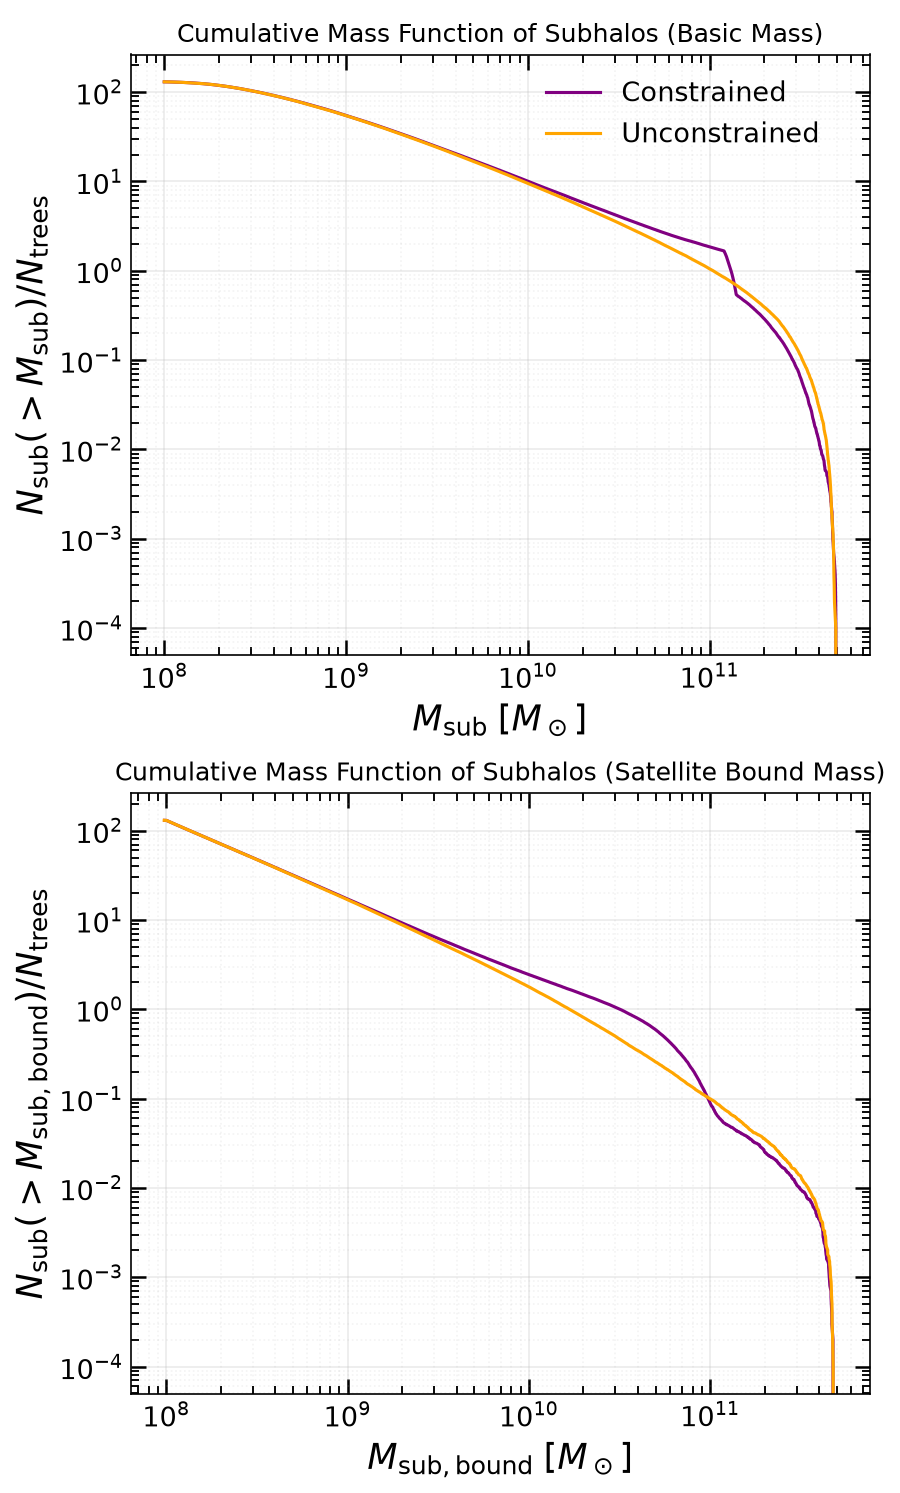

In [13]:
fig, ax = plt.subplots(2, 1, figsize= (6, 10), dpi= 150)

ax[0].plot(constrained_x_bm, constrained_y_bm, color= "purple")
ax[0].plot(unconstrained_x_bm, unconstrained_y_bm, color= "orange")
ax[0].set_xscale("log")
ax[0].set_yscale("log")

ax[0].set_xlabel(r"$M_{\rm sub}\;[M_\odot]$", fontsize=17)
ax[0].set_ylabel(r"$N_{\rm sub}(>M_{\rm sub})/ N_{\rm trees}$", fontsize=17)

ax[0].tick_params(axis="both", which="major", labelsize=13, direction="in", length=7, width=1.2)
ax[0].tick_params(axis="both", which="minor", direction="in", length=4, width=0.9)
ax[0].tick_params(top=True, right=True, which="both")

ax[0].grid(True, which="major", linestyle="-", alpha=0.25)
ax[0].grid(True, which="minor", linestyle=":", alpha=0.15)
ax[0].title.set_text("Cumulative Mass Function of Subhalos (Basic Mass)")

ax[1].plot(constrained_x_sbm, constrained_y_sbm, color= "purple")
ax[1].plot(unconstrained_x_sbm, unconstrained_y_sbm, color= "orange")
ax[1].set_xscale("log")
ax[1].set_yscale("log")

ax[1].set_xlabel(r"$M_{\rm sub, bound}\;[M_\odot]$", fontsize=17)
ax[1].set_ylabel(r"$N_{\rm sub}(>M_{\rm sub, bound})/ N_{\rm trees}$", fontsize=17)

ax[1].tick_params(axis="both", which="major", labelsize=13, direction="in", length=7, width=1.2)
ax[1].tick_params(axis="both", which="minor", direction="in", length=4, width=0.9)
ax[1].tick_params(top=True, right=True, which="both")

ax[1].grid(True, which="major", linestyle="-", alpha=0.25)
ax[1].grid(True, which="minor", linestyle=":", alpha=0.15)
ax[1].title.set_text("Cumulative Mass Function of Subhalos (Satellite Bound Mass)")

fig.legend(["Constrained", "Unconstrained"], fontsize=13, loc="upper right", frameon=False, borderpad=2.5)
fig.tight_layout()
plt.show()


## SMCs Still Associated with their Subhalos vs Not Associated

In [14]:
bound_smcs = selected[
    (selected["nodeLabelIsLMCSubhalo"] == 1)
]
regular_bound_smcs = regular_candidates[
    (regular_candidates["nodeLabelIsLMCSubhalo"] == 1)
]
special_bound_smcs = special_candidates[
    (special_candidates["nodeLabelIsLMCSubhalo"] == 1)
]

unbound_smcs = selected[
    (selected["nodeLabelIsLMCSubhalo"] == 0)
]
regular_unbound_smcs = regular_candidates[
    (regular_candidates["nodeLabelIsLMCSubhalo"] == 0)
]
special_unbound_smcs = special_candidates[
    (special_candidates["nodeLabelIsLMCSubhalo"] == 0)
]

print (bound_smcs["tree_id"].to_list())
print (regular_bound_smcs["tree_id"].to_list())
print (special_bound_smcs["tree_id"].to_list())
print (unbound_smcs["tree_id"].to_list())
print (regular_unbound_smcs["tree_id"].to_list())
print (special_unbound_smcs["tree_id"].to_list())
print("Number of regular bound SMC candidates:", len(regular_bound_smcs))
print("Number of special bound SMC candidates:", len(special_bound_smcs))
print("Number of bound SMC candidates:", len(bound_smcs))

[9910, 9838, 9990, 9787, 9950, 9761, 9859, 9656, 9785, 9736, 9608, 9480, 9550, 9670, 9858, 9681, 9585, 9806, 9542, 9887, 9781, 9192, 9526, 9475, 9810, 9478, 9446, 9048, 9137, 9379, 9400, 8985, 9685, 9334, 9994, 9201, 9324, 9428, 9158, 8780, 9380, 8505, 8969, 9357, 9551, 9964, 8825, 8995, 9462, 9326, 8729, 9278, 8247, 8913, 8681, 9682, 9230, 9635, 8151, 8007, 8710, 9349, 8345, 8973, 7640, 7767, 7678, 8755, 7497, 8673, 8799, 9530, 8532, 9170, 7431, 8831, 7017, 9930, 7224, 7239, 7054, 7481, 6977, 8071, 8134, 8445, 8086, 9697, 8246, 6440, 6571, 7049, 8222, 9775, 8039, 6449, 7816, 6475, 8035, 6615, 7783, 8061, 9203, 8544, 7635, 5768, 5921, 6425, 7655, 7699, 8049, 5806, 5825, 7773, 7622, 7222, 7646, 9649, 5895, 7629, 7459, 5192, 8762, 5000, 7351, 5201, 4809, 5640, 5009, 4961, 6406, 4769, 4520, 6935, 5225, 7027, 4328, 4233, 5033, 6708, 4529, 6627, 4481, 4937, 4385, 5830, 5208, 6911, 4551, 6734, 6813, 4145, 4145, 4171, 3752, 8809, 8723, 4361, 6621, 3608, 6147, 9556, 3646, 6871, 3225, 7062, 359

## Spatial Directions of SMC Candidates

In [15]:
x_regular_bound = regular_bound_smcs["satellitePositionX"].to_list()
y_regular_bound = regular_bound_smcs["satellitePositionY"].to_list()
z_regular_bound = regular_bound_smcs["satellitePositionZ"].to_list()

x_special_bound = special_bound_smcs["satellitePositionX"].to_list()
y_special_bound = special_bound_smcs["satellitePositionY"].to_list()
z_special_bound = special_bound_smcs["satellitePositionZ"].to_list()

x_regular_unbound = regular_unbound_smcs["satellitePositionX"].to_list()
y_regular_unbound = regular_unbound_smcs["satellitePositionY"].to_list()
z_regular_unbound = regular_unbound_smcs["satellitePositionZ"].to_list()

x_special_unbound = special_unbound_smcs["satellitePositionX"].to_list()
y_special_unbound = special_unbound_smcs["satellitePositionY"].to_list()
z_special_unbound = special_unbound_smcs["satellitePositionZ"].to_list()

x_actual = 0.0164
y_actual = -0.0167
z_actual = -0.0154

## 3d Plot of Spatial Distributions of SMC Candidates

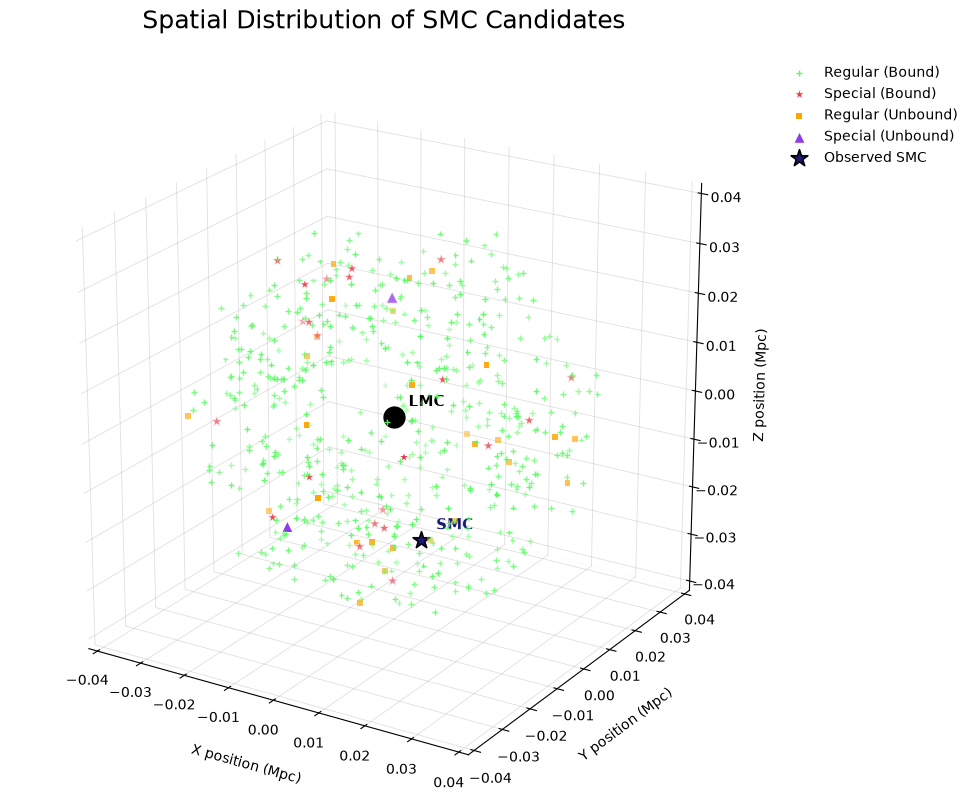

In [16]:
import matplotlib.pyplot as plt

GREEN  = "#5DF965"
RED    = "#E63B48"
ORANGE = "#FFA500"
PURPLE = "#9039E6"
DARK_BLUE = "#1A1A7A"

fig = plt.figure(figsize=(10, 8), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    x_regular_bound, y_regular_bound, z_regular_bound,
    s=18,
    c=GREEN,
    marker="+",
    alpha=1.0,
    linewidths=1.0,
    label="Regular (Bound)"
)

ax.scatter(
    x_special_bound, y_special_bound, z_special_bound,
    s=70,
    c=RED,
    marker="*",
    alpha=1.0,
    edgecolors="white",
    linewidths=0.8,
    label="Special (Bound)"
)

ax.scatter(
    x_regular_unbound, y_regular_unbound, z_regular_unbound,
    s=18,
    c=ORANGE,
    marker="s",
    alpha=1.0,
    edgecolors="none",
    label="Regular (Unbound)"
)

ax.scatter(
    x_special_unbound, y_special_unbound, z_special_unbound,
    s=70,
    c=PURPLE,
    marker="^",
    alpha=1.0,
    edgecolors="white",
    linewidths=0.8,
    label="Special (Unbound)"
)

ax.scatter(
    [0], [0], [0],
    s=220,
    marker="o",
    c="black",
    edgecolors="black",
    linewidths=1.2,
    depthshade=False,
    label="_nolegend_"
)

ax.scatter(
    [x_actual], [y_actual], [z_actual],
    s=160,
    marker="*",
    c=DARK_BLUE,
    edgecolors="black",
    linewidths=1.2,
    depthshade=False,
    label="Observed SMC"
)

ax.text(
    0.002, 0.002, 0.002,
    "LMC",
    fontsize=11,
    fontweight="bold",
    color="black"
)

ax.text(
    x_actual + 0.002, y_actual + 0.002, z_actual + 0.002,
    "SMC",
    fontsize=11,
    fontweight="bold",
    color=DARK_BLUE
)

ax.set_title(
    "Spatial Distribution of SMC Candidates",
    fontsize=18,
    pad=18
)

ax.set_xlabel("X position (Mpc)", labelpad=10)
ax.set_ylabel("Y position (Mpc)", labelpad=10)
ax.set_zlabel("Z position (Mpc)", labelpad=10)

ax.view_init(elev=22, azim=-58)
ax.set_box_aspect((1, 1, 1))

ax.set_xlim(-0.042, 0.042)
ax.set_ylim(-0.042, 0.042)
ax.set_zlim(-0.042, 0.042)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis.pane.set_facecolor((1, 1, 1, 1))
    axis.pane.set_alpha(0.04)
    axis._axinfo["grid"]["color"] = (0.65, 0.65, 0.65, 0.35)
    axis._axinfo["grid"]["linewidth"] = 0.6

plt.show()

## Plot of Different Projections

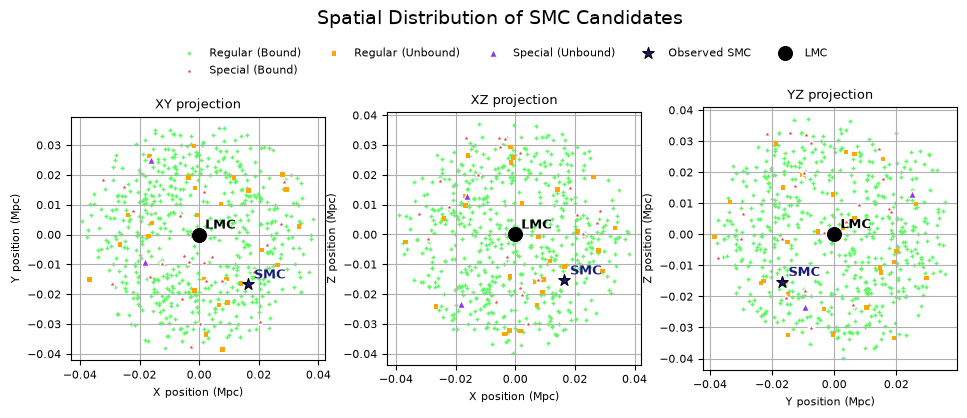

In [17]:
GREEN  = "#5DF965"
RED    = "#E63B48"
ORANGE = "#FFA500"
PURPLE = "#9039E6"

fig, axes = plt.subplots(
    1, 3,
    figsize=(9.6, 5.4),
    dpi=100
)

# These reproduce the panel positions in the 960 × 540 reference.
fig.subplots_adjust(
    left=0.069,
    right=0.992,
    bottom=0.100,
    top=0.795,
    wspace=0.245
)

projections = [
    (
        axes[0],
        "XY projection",
        "X position (Mpc)",
        "Y position (Mpc)",
        (
            (x_regular_bound,   y_regular_bound),
            (x_special_bound,   y_special_bound),
            (x_regular_unbound, y_regular_unbound),
            (x_special_unbound, y_special_unbound),
            (x_actual, y_actual)
        )
    ),
    (
        axes[1],
        "XZ projection",
        "X position (Mpc)",
        "Z position (Mpc)",
        (
            (x_regular_bound,   z_regular_bound),
            (x_special_bound,   z_special_bound),
            (x_regular_unbound, z_regular_unbound),
            (x_special_unbound, z_special_unbound),
            (x_actual, z_actual)
        )
    ),
    (
        axes[2],
        "YZ projection",
        "Y position (Mpc)",
        "Z position (Mpc)",
        (
            (y_regular_bound,   z_regular_bound),
            (y_special_bound,   z_special_bound),
            (y_regular_unbound, z_regular_unbound),
            (y_special_unbound, z_special_unbound),
            (y_actual, z_actual)
        )
    ),
]

for i, (ax, title, xlabel, ylabel, data) in enumerate(projections):
    regular_bound, special_bound, regular_unbound, special_unbound, actual = data

    # Labels are needed only on the first axes for the figure-wide legend.
    labels = (
        "Regular (Bound)",
        "Special (Bound)",
        "Regular (Unbound)",
        "Special (Unbound)",
    ) if i == 0 else ("_nolegend_",) * 4

    ax.scatter(
        *regular_bound,
        s=10,
        c=GREEN,
        marker="+",
        linewidths=1.0,
        label=labels[0],
        zorder=1
    )

    ax.scatter(
        *special_bound,
        s=30,
        c=RED,
        marker="*",
        edgecolors="white",
        linewidths=0.8,
        label=labels[1],
        zorder=3
    )

    ax.scatter(
        *regular_unbound,
        s=10,
        c=ORANGE,
        marker="s",
        edgecolors="none",
        label=labels[2],
        zorder=2
    )

    ax.scatter(
        *special_unbound,
        s=30,
        c=PURPLE,
        marker="^",
        edgecolors="white",
        linewidths=0.8,
        label=labels[3],
        zorder=4
    )

    ax.scatter(
        *actual,
        s=75,
        c=DARK_BLUE,
        marker="*",
        edgecolors="black",
        linewidths=0.8,
        label="Observed SMC" if i == 0 else "_nolegend_",
        zorder=9
    )

    ax.scatter(
        [0], [0],
        s=100,
        c="black",
        marker="o",
        edgecolors="black",
        linewidths=0.8,
        label="LMC" if i == 0 else "_nolegend_",
        zorder=10
    )

    ax.text(
        actual[0] + 0.002,
        actual[1] + 0.002,
        "SMC",
        fontsize=9,
        fontweight="bold",
        color=DARK_BLUE,
        zorder=12
    )

    ax.text(
        0.002, 0.002,
        "LMC",
        fontsize=9,
        fontweight="bold",
        color="black",
        zorder=11
    )

    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(axis="both", labelsize=8)

    # Preserve equal physical scaling while allowing the different
    # automatically calculated limits seen in the reference.
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True)

fig.suptitle(
    "Spatial Distribution of SMC Candidates",
    x=0.516,
    y=0.872,
    fontsize=14
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.519, 0.820),
    ncol=5,
    frameon=False,
    fontsize=8,
    columnspacing=2.0,
    handletextpad=0.8
)

plt.show()


## Histogram of Absolute Distances of SMC Candidates

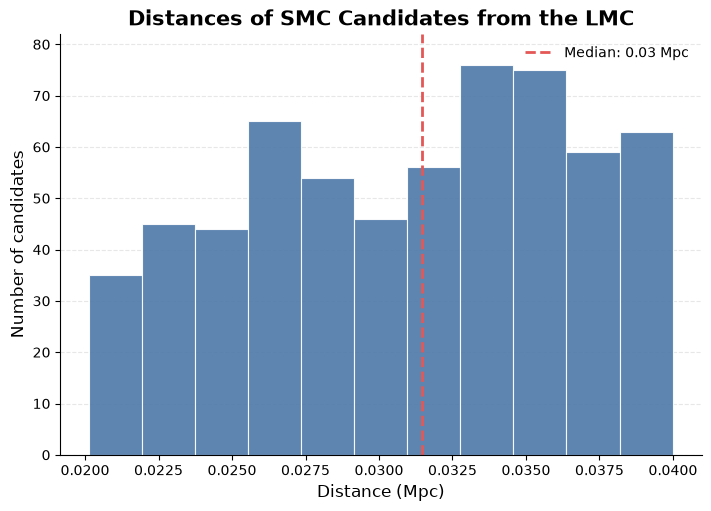

In [25]:
distances = selected["absolute_distance"].dropna()

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

ax.hist(
    distances,
    bins="auto",
    color="#4C78A8",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
)

median_distance = distances.median()
ax.axvline(
    median_distance,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_distance:.2f} Mpc",
)

ax.set(
    title="Distances of SMC Candidates from the LMC",
    xlabel="Distance (Mpc)",
    ylabel="Number of candidates",
)

ax.title.set_fontsize(15)
ax.title.set_weight("bold")
ax.xaxis.label.set_fontsize(12)
ax.yaxis.label.set_fontsize(12)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)
ax.margins(y=0.08)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.show()

## Constrained and Unconstrained SMC Concentrations